In [53]:
import sys
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.append(os.getcwd())

from src.models import ResNetFineTuned, ResNetFrozen, CNN
from src.train import train
from src.dataset import HAM10000Dataset, get_train_transforms, get_eval_transforms, compute_class_weights, IMAGENET_MEAN, IMAGENET_STD, DX_TO_IDX, IDX_TO_DX
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS")
else:
    print("CUDA not available, using CPU")
    device = torch.device("cpu")

Using CUDA


Load in Test Data

In [ ]:
test_df = pd.read_csv('data/splits/test.csv')
image_dir = os.path.join(os.getcwd(), 'data', 'HAM10000_images')
test_dataset = HAM10000Dataset(test_df, image_dir, get_eval_transforms())
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

CNN Evaluation

In [56]:
cnn = CNN(
   in_channels=3,
   num_classes=7,
   n_blocks=4,
   n_layers_per_block=6,
   channels_l0=16,
   stem_kernel_size=11,
   stem_stride=2,
   block_stride=2,
   channel_growth_factor=2,
   dropout_p=0.3 
)

cnn.load_state_dict(torch.load(r"models\baseline_cnn_0707_161948.th"))

cnn.to(device)
cnn.eval()

CNN(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(11, 11), stride=(2, 2), padding=(5, 5))
    (1): ReLU()
    (2): Block(
      (conv_layers): ModuleList(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1-5): 5 x Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (batch_norms): ModuleList(
        (0-5): 6 x BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (relu): ReLU()
      (skip): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2))
    )
    (3): Block(
      (conv_layers): ModuleList(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1-5): 5 x Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (batch_norms): ModuleList(
        (0-5): 6 x BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (relu): ReLU()
      (skip): Conv2d(3

In [57]:
cnn_preds = []
cnn_labels = []
cnn_confidences = []
with torch.inference_mode():
    cnn.eval() # set model to evaluation mode (parameter training = False)
    for batch_idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        logits = cnn(images)  # forward pass calculates logit predictions for img
        probs = torch.softmax(logits, dim=1)
        confidence, preds = probs.max(dim=1)
        cnn_confidences.append(confidence.cpu().numpy())
        cnn_preds.append(preds.cpu().numpy())
        cnn_labels.append(labels.cpu().numpy())

cnn_preds = np.concatenate(cnn_preds)
cnn_labels = np.concatenate(cnn_labels)
cnn_confidences = np.concatenate(cnn_confidences)

class_names = [IDX_TO_DX[i] for i in range(len(DX_TO_IDX))]
report = classification_report(cnn_labels, cnn_preds, target_names=class_names, zero_division=0)
print(report)

correct_mask = (cnn_preds == cnn_labels)
print(f"Mean confidence when correct:   {cnn_confidences[correct_mask].mean():.3f}")
print(f"Mean confidence when incorrect: {cnn_confidences[~correct_mask].mean():.3f}")

              precision    recall  f1-score   support

       akiec       0.34      0.65      0.44        52
         bcc       0.36      0.62      0.46        76
         bkl       0.45      0.29      0.35       162
          df       0.17      0.53      0.26        15
         mel       0.39      0.56      0.46       164
          nv       0.94      0.76      0.84       990
        vasc       0.33      0.90      0.48        21

    accuracy                           0.68      1480
   macro avg       0.43      0.62      0.47      1480
weighted avg       0.76      0.68      0.70      1480

Mean confidence when correct:   0.762
Mean confidence when incorrect: 0.497


Frozen ResNet evaluation

In [58]:
resnet_frozen = ResNetFrozen()
resnet_frozen.load_state_dict(torch.load(r"models\ResNetFrozen_0707_212302.th"))

resnet_frozen.to(device)
resnet_frozen.eval()

ResNetFrozen(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, 

In [64]:
resnet_frozen_preds = []
resnet_frozen_labels = []
resnet_frozen_confidences = []
with torch.inference_mode():
    resnet_frozen.eval() # set model to evaluation mode (parameter training = False)
    for batch_idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        logits = resnet_frozen(images)  # forward pass calculates logit predictions for img
        probs = torch.softmax(logits, dim=1)
        confidence, preds = probs.max(dim=1)
        resnet_frozen_confidences.append(confidence.cpu().numpy())
        resnet_frozen_preds.append(preds.cpu().numpy())
        resnet_frozen_labels.append(labels.cpu().numpy())

resnet_frozen_preds = np.concatenate(resnet_frozen_preds)
resnet_frozen_labels = np.concatenate(resnet_frozen_labels)
resnet_frozen_confidences = np.concatenate(resnet_frozen_confidences)

class_names = [IDX_TO_DX[i] for i in range(len(DX_TO_IDX))]
report = classification_report(resnet_frozen_labels, resnet_frozen_preds, target_names=class_names, zero_division=0)
print(report)

correct_mask = (resnet_frozen_preds == resnet_frozen_labels)
print(f"Mean confidence when correct:   {resnet_frozen_confidences[correct_mask].mean():.3f}")
print(f"Mean confidence when incorrect: {resnet_frozen_confidences[~correct_mask].mean():.3f}")

              precision    recall  f1-score   support

       akiec       0.49      0.69      0.57        52
         bcc       0.43      0.71      0.54        76
         bkl       0.50      0.53      0.52       162
          df       0.43      0.60      0.50        15
         mel       0.34      0.69      0.45       164
          nv       0.97      0.71      0.81       990
        vasc       0.45      0.67      0.54        21

    accuracy                           0.68      1480
   macro avg       0.51      0.66      0.56      1480
weighted avg       0.79      0.68      0.71      1480

Mean confidence when correct:   0.813
Mean confidence when incorrect: 0.589


Fine Tuned Resnet Evaluation

In [65]:
resnet_fine_tuned = ResNetFineTuned(["layer4", "fc"])

resnet_fine_tuned.load_state_dict(torch.load(r"models/ResNetFineTuned-Layer4Unfrozen_0708_010323.th"))

resnet_fine_tuned.to(device)
resnet_fine_tuned.eval()

Frozen:  conv1.weight
Frozen:  bn1.weight
Frozen:  bn1.bias
Frozen:  layer1.0.conv1.weight
Frozen:  layer1.0.bn1.weight
Frozen:  layer1.0.bn1.bias
Frozen:  layer1.0.conv2.weight
Frozen:  layer1.0.bn2.weight
Frozen:  layer1.0.bn2.bias
Frozen:  layer1.1.conv1.weight
Frozen:  layer1.1.bn1.weight
Frozen:  layer1.1.bn1.bias
Frozen:  layer1.1.conv2.weight
Frozen:  layer1.1.bn2.weight
Frozen:  layer1.1.bn2.bias
Frozen:  layer2.0.conv1.weight
Frozen:  layer2.0.bn1.weight
Frozen:  layer2.0.bn1.bias
Frozen:  layer2.0.conv2.weight
Frozen:  layer2.0.bn2.weight
Frozen:  layer2.0.bn2.bias
Frozen:  layer2.0.downsample.0.weight
Frozen:  layer2.0.downsample.1.weight
Frozen:  layer2.0.downsample.1.bias
Frozen:  layer2.1.conv1.weight
Frozen:  layer2.1.bn1.weight
Frozen:  layer2.1.bn1.bias
Frozen:  layer2.1.conv2.weight
Frozen:  layer2.1.bn2.weight
Frozen:  layer2.1.bn2.bias
Frozen:  layer3.0.conv1.weight
Frozen:  layer3.0.bn1.weight
Frozen:  layer3.0.bn1.bias
Frozen:  layer3.0.conv2.weight
Frozen:  layer

ResNetFineTuned(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-0

In [66]:
resnet_fine_tuned_preds = []
resnet_fine_tuned_labels = []
resnet_fine_tuned_confidences = []
with torch.inference_mode():
    resnet_fine_tuned.eval() # set model to evaluation mode (parameter training = False)
    for batch_idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        logits = resnet_fine_tuned(images)  # forward pass calculates logit predictions for img
        probs = torch.softmax(logits, dim=1)
        confidence, preds = probs.max(dim=1)
        resnet_fine_tuned_confidences.append(confidence.cpu().numpy())
        resnet_fine_tuned_preds.append(preds.cpu().numpy())
        resnet_fine_tuned_labels.append(labels.cpu().numpy())

resnet_fine_tuned_preds = np.concatenate(resnet_fine_tuned_preds)
resnet_fine_tuned_labels = np.concatenate(resnet_fine_tuned_labels)
resnet_fine_tuned_confidences = np.concatenate(resnet_fine_tuned_confidences)

class_names = [IDX_TO_DX[i] for i in range(len(DX_TO_IDX))]
report = classification_report(resnet_fine_tuned_labels, resnet_fine_tuned_preds, target_names=class_names, zero_division=0)
print(report)

correct_mask = (resnet_fine_tuned_preds == resnet_fine_tuned_labels)
print(f"Mean confidence when correct:   {resnet_fine_tuned_confidences[correct_mask].mean():.3f}")
print(f"Mean confidence when incorrect: {resnet_fine_tuned_confidences[~correct_mask].mean():.3f}")

              precision    recall  f1-score   support

       akiec       0.59      0.71      0.64        52
         bcc       0.70      0.64      0.67        76
         bkl       0.60      0.66      0.63       162
          df       0.65      0.73      0.69        15
         mel       0.52      0.51      0.51       164
          nv       0.92      0.90      0.91       990
        vasc       0.62      0.95      0.75        21

    accuracy                           0.81      1480
   macro avg       0.66      0.73      0.69      1480
weighted avg       0.81      0.81      0.81      1480

Mean confidence when correct:   0.957
Mean confidence when incorrect: 0.798


Confusion Matrix Function

In [62]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, ax=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, cbar=False,
        vmin=0, vmax=1
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    return ax

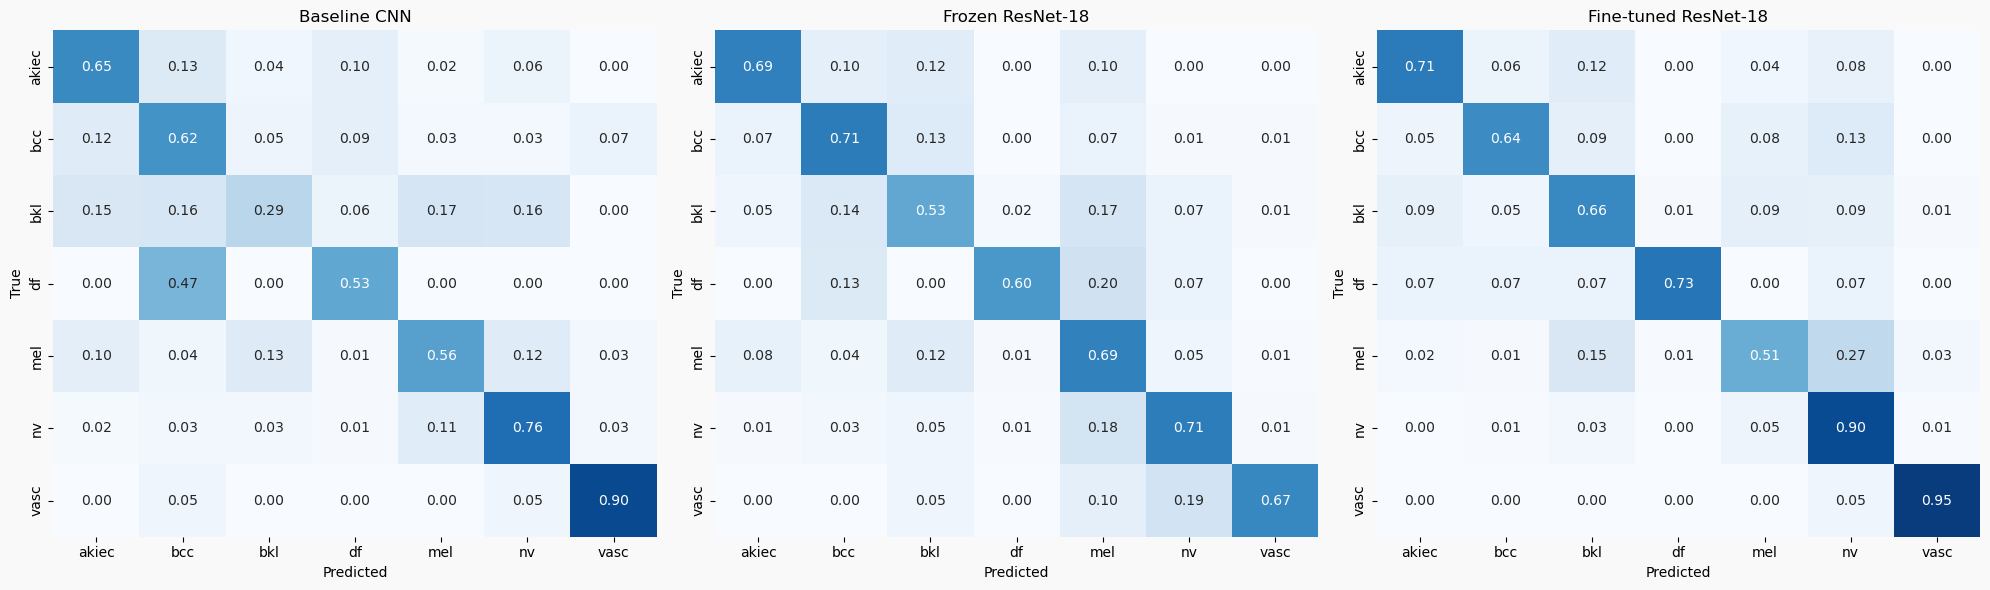

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#F9F9F9')

plot_confusion_matrix(cnn_labels, cnn_preds, class_names, "Baseline CNN", ax=axes[0])
plot_confusion_matrix(resnet_frozen_labels, resnet_frozen_preds, class_names, "Frozen ResNet-18", ax=axes[1])
plot_confusion_matrix(resnet_fine_tuned_labels, resnet_fine_tuned_preds, class_names, "Fine-tuned ResNet-18", ax=axes[2])

plt.tight_layout()
plt.savefig('evaluation_images/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()